# Acquisition notebook

Communication with Thorlabs power-meter

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import pyvisa as pv
import serial
import serial.tools.list_ports

In [3]:
from utils.pm100a import record_pm100a
from utils.oc3 import OC3
from utils.naming import make_run_dir

In [4]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

from datetime import datetime
from pathlib import Path

Set directory for data collection

In [5]:
# DATA_DIR = "data/data_pm100a"
DATA_DIR = "data/data_powermeter"
os.makedirs(DATA_DIR, exist_ok=True)

Check for PM100A and PM100D (pesto)

In [8]:
# Check available VISA resources
rm = pv.ResourceManager()
print(rm.list_resources())

('USB0::0x0699::0x039F::C010359::INSTR', 'USB0::0x1313::0x8078::P0025589::INSTR', 'USB0::0x1313::0x8079::P1007388::INSTR', 'ASRL1::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR')


In [9]:
# Connect to PM100A power meter via PyVISA
# you can use the tool Power Meter Driver Switcher to switch between the two drivers, the PM100D.dll driver and the new TLPM.dll driver. 
# Pyvisa may not recognize the PM100A with the WinUSB driver, so you may need to switch to the Visa driver. 
pm100a = rm.open_resource('USB0::0x1313::0x8079::P1007388::INSTR')  # PANDA powermeter
# pm100d = rm.open_resource('USB0::0x1313::0x8078::P0008159::INSTR')  # PESTO powermeter
pm100d = rm.open_resource('USB0::0x1313::0x8078::P0025589::INSTR')  # Musiqs powermeter
print(pm100a.query('*IDN?'))
print(pm100d.query('*IDN?'))

Thorlabs,PM100A,P1007388,2.5.0

Thorlabs,PM100D,P0025589,2.8.1



In [10]:
plist = list(serial.tools.list_ports.comports())
print(plist)

[<serial.tools.list_ports_common.ListPortInfo object at 0x00000252A9573770>, <serial.tools.list_ports_common.ListPortInfo object at 0x00000252ABA64A50>, <serial.tools.list_ports_common.ListPortInfo object at 0x00000252ABA64E10>]


In [11]:
# Connect to OC3 temperature controller via pyserial
# OC_PORT = "COM3" 
OC_PORT = "COM5"
oc3 = OC3(port=OC_PORT)
print("Connected to OC3 on port", OC_PORT, oc3.status())

Connected to OC3 on port COM5 b'j5542.600;42.598;1;04.0;0;0;1;23.973;c24/1.54p;0;0;42.600;71'


In [16]:
# Record parameters
PM_SAMPLE_DELAY = 0.1 # seconds
PM_DURATION = 5 # seconds

### Reflectivity and Transmitivity measurements

In [133]:
# Set names
# SAMPLE = "laseroptik-T004Q2"

# SAMPLE = "metallic_unknown"
# --- Cavity Mirrors --- #
# SAMPLE = "laseroptic_panda_hr"
# SAMPLE = "laseroptic_panda_roc_150"
# SAMPLE = "laseroptic_panda_coupler_5"
# MEAS = "reflectivity"

# --- EQ15B ---#
MEAS = "transmitivity"
SAMPLE = "eq15b_flat_HR426_1inch_face2"

RUN_DIR = make_run_dir(data_dir=DATA_DIR, meas=MEAS, sample=SAMPLE)

Saving data to: data/data_pm100a\transmitivity\2026-06-01_eq15b_flat_HR426_1inch_face2_001


In [134]:
ACQ_CELL = f"{MEAS}_{SAMPLE}"
print(ACQ_CELL)

transmitivity_eq15b_flat_HR426_1inch_face2


In [ ]:
# Wavelength
wavelength = 780 # nm

# Acquisition and analysis
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell(ACQ_CELL)

mean_mW, error_mW = record_pm100a(
        pm100a,
        duration_s=2,
        dt_s=PM_SAMPLE_DELAY
    )

print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")

aqm.save_acquisition(mean_mW=mean_mW, error_mW=error_mW, wavelength=wavelength, sample=SAMPLE)

INFO:1:2026_06_01__15_42_57__transmitivity_eq15b_flat_HR426_1inch_face2


Mean power = 22.476131 ± 0.032683 mW


### Long time fluctuations

In [12]:
MEAS = "laser_fluctuation"
# SAMPLE = "ppktp_svenska_10"
SAMPLE = "shg_injection"

In [13]:
RUN_DIR = make_run_dir(data_dir=DATA_DIR, meas=MEAS, sample=SAMPLE)

Saving data to: data/data_powermeter\laser_fluctuation\2026-06-18_shg_injection_001


In [14]:
ACQ_CELL = f"{MEAS}_{SAMPLE}"

In [17]:
# Wavelength
wavelength = 780 # nm
duration_s = 60*60 # 1h
head = "pm100d"

# Acquisition and analysis
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell(ACQ_CELL)

mean_mW, error_mW, values_mW = record_pm100a(
        pm100d,
        duration_s=duration_s,
        dt_s=PM_SAMPLE_DELAY
    )

print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")

aqm.save_acquisition(mean_mW=mean_mW, error_mW=error_mW, values_mW=values_mW, wavelength=wavelength, sample=SAMPLE, head=head)

INFO:1:2026_06_18__08_27_01__laser_fluctuation_shg_injection


KeyboardInterrupt: 

In [18]:
p2p_rel = (np.max(values_mW) - np.min(values_mW)) / np.mean(values_mW)
print(f"Peak-to-peak fluctuation = {100*p2p_rel:.3f}%")

NameError: name 'values_mW' is not defined

In [61]:
mu = np.mean(values_mW)
sigma = np.std(values_mW)

rms_pct = 100 * sigma / mu

print(f"RMS relatif = {rms_pct:.3f} %")

RMS relatif = 9.960 %


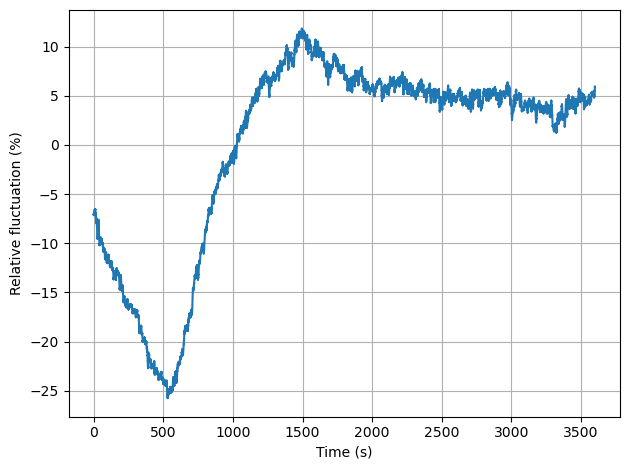

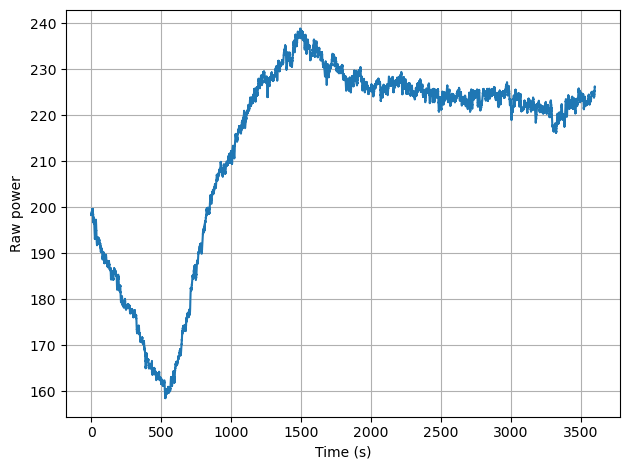

RMS fluctuation = 9.960 %


In [63]:
# Relative fluctuation with respect to the mean power
rel_fluct_pct = 100 * (values_mW - np.mean(values_mW)) / np.mean(values_mW)

# Time array
time_s = np.linspace(0, 60*60, len(values_mW))

# Plot
plt.figure()
plt.plot(time_s, rel_fluct_pct)
plt.xlabel("Time (s)")
plt.ylabel("Relative fluctuation (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(time_s, values_mW)
plt.xlabel("Time (s)")
plt.ylabel("Raw power")
plt.grid(True)
plt.tight_layout()
plt.show()

# RMS fluctuation
rms_pct = 100 * np.std(values_mW) / np.mean(values_mW)
print(f"RMS fluctuation = {rms_pct:.3f} %")